In [1]:
import numpy as np 
import pandas as pd 
%matplotlib inline 
import matplotlib.pyplot as plt 
from matplotlib.patches import Patch

import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')
from importlib import reload
import figure_utils
reload(figure_utils)
from figure_utils import (
    format_model_str,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    set_bar_labels,

)


## Set figure out dir 

fig_out_dir = Path("CCN_2026_figs")
fig_out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
### Get results from dir

def get_results_from_dict(results_dict):
    row_records = []
    for score_type, score_dict in results_dict.items():
        if "scores" in score_type:
            for parameter, param_dict in score_dict.items():
                for fold_idx, score in enumerate(param_dict['values']):
                    record = {
                        'parameter': parameter,
                        'score_type': score_type,
                        'score': score,
                        'fold': fold_idx,
                    }
                    row_records.append(record)
    return row_records

param_decoding_results_dir = Path("parameter_decoding_v2")
results_pkls = list(param_decoding_results_dir.rglob("*kell*/*_r2_decoding_values*.pkl"))
results_pkls += list(param_decoding_results_dir.rglob("*audiomae*/*_r2_decoding_values*.pkl"))

# add audio

results_dfs = []
for ix, file_path in enumerate(results_pkls):
    results_dict = pd.read_pickle(file_path)
    results_records = get_results_from_dict(results_dict)

    results_df = pd.DataFrame(results_records)
    results_df['layer'] = file_path.stem.split('_r2')[0]
    
    # Use format_model_str from figure_utils to get normalized model name
    model_name, arch, _, eq_lmbda = format_model_str(file_path)
    if 'audiomae' in file_path.parent.name:
        model_name = "AudioMAE"
        arch = "AudioMAE"
    results_df['model_name'] = model_name
    results_df['model'] = arch
    results_df['eq_lmbda'] = eq_lmbda if eq_lmbda else ''

    results_dfs.append(results_df)

results = pd.concat(results_dfs, axis=0, ignore_index=True).drop_duplicates()

# Pivot so score_type becomes two columns: r2_scores and pr2_scores
id_cols = ['parameter', 'layer', 'model_name', 'model', 'eq_lmbda', 'fold']
results = results.pivot(index=id_cols, columns='score_type', values='score').reset_index()

In [3]:
results

score_type,parameter,layer,model_name,model,eq_lmbda,fold,pr2_scores,r2_scores
0,% Time warp,norm,AudioMAE,AudioMAE,,0,0.793848,0.792862
1,% Time warp,norm,AudioMAE,AudioMAE,,1,0.829944,0.829632
2,% Time warp,norm,AudioMAE,AudioMAE,,2,0.800372,0.799739
3,% Time warp,norm,AudioMAE,AudioMAE,,3,0.817607,0.816097
4,% Time warp,norm,AudioMAE,AudioMAE,,4,0.810389,0.809061
...,...,...,...,...,...,...,...,...
2515,dB SNR,relufc,CochCNN9 supervised word,kell2018,,0,0.152695,-1.764627
2516,dB SNR,relufc,CochCNN9 supervised word,kell2018,,1,0.154401,-1.453614
2517,dB SNR,relufc,CochCNN9 supervised word,kell2018,,2,0.137116,-1.604089
2518,dB SNR,relufc,CochCNN9 supervised word,kell2018,,3,0.192389,-1.350274


In [4]:
# Show normalized model names (used for plotting)
results.model_name.value_counts()

model_name
CochCNN9 scaled aud. event        210
CochCNN9 scaled ssl λ=0.5         210
CochCNN9 scaled ssl λ=0.0         210
CochCNN9 ssl λ=0.0                210
CochCNN9 ssl λ=0.1                210
CochCNN9 supervised audioset      210
CochCNN9 ssl λ=0.2                210
CochCNN9 ssl λ=0.3                210
CochCNN9 ssl λ=0.4                210
CochCNN9 supervised word          210
CochCNN9 supervised multi-task    210
CochCNN9 ssl λ=0.5                175
AudioMAE                           35
Name: count, dtype: int64

In [5]:
# Use standardized model order and colors from figure_utils
# Filter to models that are actually in the data
all_models_in_data = results['model_name'].unique()
std_order = get_standard_hue_order()
model_plot_order = [m for m in std_order if m in all_models_in_data]
# Add any models in data that aren't in standard order
extra_models = [m for m in all_models_in_data if m not in model_plot_order]
model_plot_order = model_plot_order + extra_models

# Build palette using figure_utils
base_colors = get_standard_base_colors()
palette_dict = build_model_palette(model_plot_order, base_colors)
palette_dict['AudioMAE'] = "cyan"

print("Models in data:", model_plot_order)

Models in data: ['CochCNN9 supervised multi-task', 'CochCNN9 supervised word', 'CochCNN9 supervised audioset', 'CochCNN9 scaled aud. event', 'CochCNN9 ssl λ=0.0', 'CochCNN9 ssl λ=0.1', 'CochCNN9 ssl λ=0.2', 'CochCNN9 ssl λ=0.3', 'CochCNN9 ssl λ=0.4', 'CochCNN9 ssl λ=0.5', 'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 scaled ssl λ=0.5', 'AudioMAE']


In [6]:
PARAMETER_ORDER = [
                'dB SNR',
                '% Time warp',
                'Time shift (s)',
                'Pitch (semitones)',
                'Filter high cutoff',
                'Filter low cutoff',
                'Filter order',
]

# Make main figures

Text(0.5, 1, 'CochCNN9 parameter decoding ')

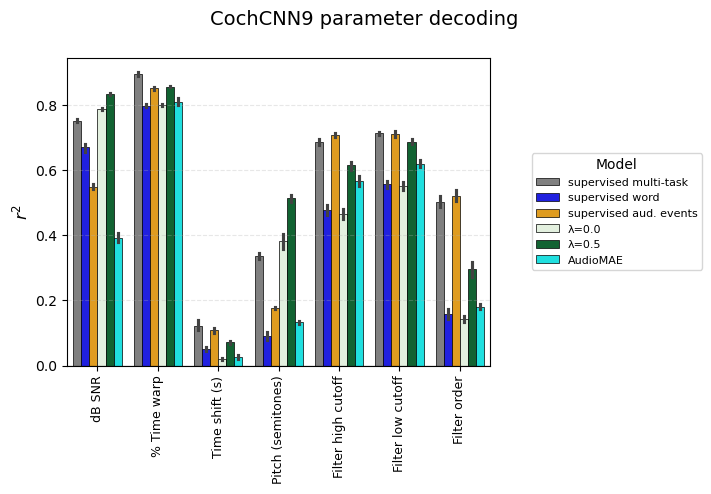

In [7]:
# -- Name models for plot -- 
main_plot_models  = [
        'CochCNN9 supervised multi-task',
        'CochCNN9 supervised word',
        'CochCNN9 supervised audioset',
        # 'CochDNN9 scaled supervised',
        'CochCNN9 ssl λ=0.0',
        'CochCNN9 ssl λ=0.5',
        # 'CochDNN9 scaled ssl λ=0.0',
        # 'CochDNN9 scaled ssl λ=0.5',
        'AudioMAE',
        'Whisper',
]


kell_results = results[results.model_name.isin(main_plot_models)].reset_index(drop=True)

model_order = [m for m in model_plot_order if m in kell_results['model_name'].unique()]

# Create visualization with barplot (3) : legend (1) ratio
panel_size = 4
fig, axes = plt.subplots(1, 2, figsize=( panel_size*2 , panel_size), 
                          gridspec_kw={'width_ratios': [3, 1]})
# axes = axes.flatten()  # Flatten to 1D array for easier indexing
layers = ['relu4', 'norm']

idx = 0

layer_data = kell_results[kell_results['layer'].isin(layers)]
    # Create grouped bar plot: parameter on x, hue by model
sns.barplot(
    data=layer_data,
    x='parameter',
    y='pr2_scores',
    hue='model_name',
    hue_order=model_order,
    order=PARAMETER_ORDER,
    ax=axes[idx],
    palette=[palette_dict[m] for m in model_order],
    linewidth=0.5,
    linestyle='-',
    edgecolor='black',
    capsize=0,
)

# axes[idx].set_title(layer, fontsize=12)
axes[idx].set_xlabel('')
axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
axes[idx].axhline(y=0, color='black', linewidth=0.8)

# Rotate x-axis labels 90 degrees and center them under tick groups
axes[idx].tick_params(axis='x', rotation=90, labelsize=9)
# Get the x-tick positions and labels
tick_positions = axes[idx].get_xticks()
tick_labels = axes[idx].get_xticklabels()
# Set labels with centered alignment
for label in tick_labels:
    label.set_ha('center')
    label.set_rotation(90)

# Only show ylabel on first subplot (top left)
axes[idx].set_ylabel('$r^2$', fontsize=12)


# Store legend handles and labels from first plot before removing
handles, labels = axes[idx].get_legend_handles_labels()
# Remove legend from all subplots
axes[idx].legend().remove()

# Put legend in the middle of the 6th panel (index 5)
axes[-1].axis('off')  # Hide axes but keep the space
# Create legend with formatted model labels using model_label()
legend_labels = [model_label(m) for m in model_order]
axes[-1].legend(handles, legend_labels, title='Model', loc='center', fontsize=8, frameon=True)

plt.suptitle('CochCNN9 parameter decoding ', fontsize=14,  y=1)
# Reduce whitespace between panels
# plt.subplots_adjust(wspace=0.25, hspace=1, top=0.9, bottom=0.1, left=0.08, right=0.95)

# plt.savefig(outfig_dir/'relufc_param_decoding.png', transparent=True, dpi=500, bbox_inches='tight')




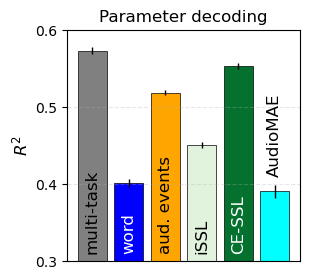

In [ ]:
panel_size = 3
fig, axes = plt.subplots(1, 1, figsize=(panel_size , panel_size))
reload(figure_utils)
from figure_utils import (set_bar_labels)

x_pos = np.arange(len(model_order))

## models for comparison 
plot_model_order = [
'CochCNN9 supervised multi-task',
 'CochCNN9 supervised word',
 'CochCNN9 supervised audioset',
 'CochCNN9 ssl λ=0.0',
 'CochCNN9 ssl λ=0.5',
 "AudioMAE",
 "Whisper",
]

ax = axes # [1] 

layers = ["relu4", "norm", "ln_post"]

for_plot = results[results.model_name.isin(plot_model_order) & (results.layer.isin(layers))]
model_order = [m for m in model_plot_order if m in for_plot['model_name'].unique()]

# Per run (fold): mean over parameters; then mean and std across runs
run_means = for_plot.groupby(['model_name', 'fold'])['pr2_scores'].mean().reset_index()
run_means = run_means.rename(columns={'pr2_scores': 'mean_r2_per_run'})
avg_data = run_means.groupby('model_name')['mean_r2_per_run'].agg(['mean', 'std']).reset_index()
avg_data.columns = ['model_name', 'mean_r2', 'std_r2']

# Reorder by model_order (handle missing models gracefully)
available_models = [m for m in model_order if m in avg_data['model_name'].values]
avg_data = avg_data.set_index('model_name').loc[available_models].reset_index()

# Create barplot
bars = ax.bar(x_pos[:len(available_models)], avg_data['mean_r2'].values, 
       color=[palette_dict[m] for m in available_models], 
       edgecolor='black', linewidth=0.5)

# Add error bars
ax.errorbar(x_pos[:len(available_models)], avg_data['mean_r2'].values, 
            yerr=avg_data['std_r2'].values,
            fmt='none', color='black', capsize=0, capthick=1, elinewidth=1)


white_text_substrs=['word', 'CE']

set_bar_labels(ax,
               bars,
               [model_label(m, use_ssl_names=True).replace('supervised ', '') for m in available_models],
               white_text_substrs=white_text_substrs, 
               ymin_bars = 0.31,
               no_olap_pad=0.02,
               inside_fit_tolerance=0.1
            #    fontsize=10,
            #    x_shift_size=0.0125,
                   )    
ax.set_xticks([]) #x_pos[:len(available_models)])
ax.set_xticklabels([]) #[model_label(m, with_ssl=True) for m in available_models], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linewidth=0.8)

# Only show ylabel on leftmost panels
ax.set_ylabel('$R^2$', fontsize=12)
# ax.set_xlabel('SSL $\\lambda$', fontsize=12)

ax.set_title("Parameter decoding")
ax.set_ylim(0.3, 0.6)
ax.set_yticks(np.linspace(0.3,0.6,4));



# plt.savefig(fig_out_dir / "avg_param_decoding_core_models_w_AudioMAE.pdf", bbox_inches='tight',)# transparent=True)


